16 fichiers trouvés
Taille vidéo : 888 x 930
Temps moyen passé par chambre (secondes) :
chamber
Chambre_1        1370.072917
Chambre_3         759.843750
Outside           509.604167
Chambre_2         376.708333
Decision_zone     133.229167
dtype: float64

Écart-type :
chamber
Chambre_1        976.137310
Chambre_3        813.006973
Outside          802.907379
Chambre_2        442.285100
Decision_zone    135.613092
dtype: float64


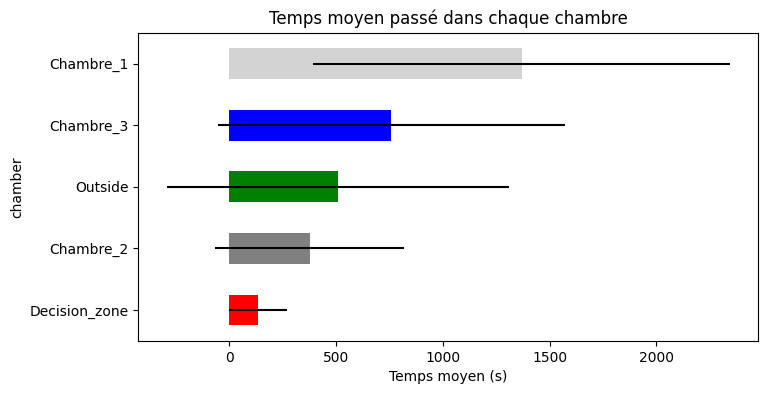

In [3]:
import json
from pathlib import Path
import numpy as np
import sys
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path("..").resolve()
sys.path.append(str(project_root))

from Calibration.Parameters import CHAMBERS_COLORS

# ---------------------------
# Charger le masque et préparer la carte des chambres
# ---------------------------
tracking_folder = project_root / "Data"
tracking_files = list(tracking_folder.rglob("*tracking.json"))

print(len(tracking_files), "fichiers trouvés")

# Choisir une vidéo pour récupérer la taille (toutes doivent avoir la même taille)
sample_video = str(tracking_files[0]).replace("_tracking.json", ".mp4")
cap = cv2.VideoCapture(sample_video)
ret, frame = cap.read()
if not ret:
    raise ValueError(f"Impossible d'ouvrir la vidéo {sample_video}")
video_height, video_width = frame.shape[:2]
cap.release()
print(f"Taille vidéo : {video_width} x {video_height}")

# Charger et redimensionner le masque
mask_path = project_root / "Calibration" / "Maze_pictures" / "Maze_mask_top_painted.png"
mask = cv2.imread(str(mask_path))
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
mask_resized = cv2.resize(mask, (video_width, video_height), interpolation=cv2.INTER_NEAREST)

# Créer la carte des chambres
COLOR_MAP = {"Red": (255,0,0), "Green": (0,255,0), "Blue": (0,0,255), "White": (255,255,255)}
CHAMBERS_RGB = {chamber: COLOR_MAP[color] for chamber, color in CHAMBERS_COLORS.items()}
chamber_index = {"Chambre_1": 1, "Decision_zone": 2, "Chambre_2": 3, "Chambre_3": 4}
chamber_map = np.zeros(mask_resized.shape[:2], dtype=int)
for chamber, rgb in CHAMBERS_RGB.items():
    mask_pixels = np.all(mask_resized == rgb, axis=2)
    chamber_map[mask_pixels] = chamber_index[chamber]

# ---------------------------
# Analyser tous les fichiers et stocker les résultats
# ---------------------------
results_list = []

for file in tracking_files:
    
    cancel_file = file.with_name(file.stem.replace("_tracking", "") + "_tracking_cancelled.txt")
    if cancel_file.exists():
        print(f"Vidéo ignorée (tracking annulé) : {file.stem}")
        continue
    
    with open(file) as f:
        data = json.load(f)

    fps = data["fps"]
    tracking = data["tracking"]
    df = pd.DataFrame(tracking)

    # Extraire les coordonnées
    df["x"] = df["position"].apply(lambda p: p["x"] if p else None)
    df["y"] = df["position"].apply(lambda p: p["y"] if p else None)
    df = df.drop(columns="position")
    df["x_int"] = df["x"].astype("Int64")
    df["y_int"] = df["y"].astype("Int64")

    # Associer chaque point à une chambre
    height, width = chamber_map.shape
    df["chamber_id"] = [
        chamber_map[y, x] if pd.notna(x) and pd.notna(y) and 0 <= x < width and 0 <= y < height else 0
        for x, y in zip(df["x_int"], df["y_int"])
    ]
    inverse_map = {v:k for k,v in chamber_index.items()}
    inverse_map[0] = "Outside"
    df["chamber"] = df["chamber_id"].map(inverse_map)

    # Calcul du temps passé par chambre
    time_spent_sec = df.groupby("chamber").size() / fps
    results_list.append(time_spent_sec)

# ---------------------------
# Créer un DataFrame combiné
# ---------------------------
all_results = pd.DataFrame(results_list).fillna(0)

# Moyenne et écart-type
mean_time = all_results.mean()
std_time = all_results.std()

# Affichage
print("Temps moyen passé par chambre (secondes) :")
print(mean_time)
print("\nÉcart-type :")
print(std_time)

# Graphique
mean_time.sort_values().plot.barh(
    xerr=std_time,
    color=["red","gray","green","blue","lightgray"],
    figsize=(8,4)
)
plt.xlabel("Temps moyen (s)")
plt.title("Temps moyen passé dans chaque chambre")
plt.show()